<a href="https://colab.research.google.com/github/erdijova/midterm-machine-learning-uts/blob/main/Midterm_ML_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Library

In [1]:
!pip install optuna
!pip install lime
!pip install mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7440a4f3c736566a8a323608db50de3899ba91764b980cc4347552e497e3a5b5
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

Import Library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import optuna
import lime
import lime.lime_tabular

import mlflow

In this project, we integrate several key Python libraries to build a transparent and optimized machine learning workflow. Pandas is utilized for reading CSV datasets, while Sklearn serves as the primary library for implementing various machine learning algorithms. The specific model we will employ is the RandomForestRegressor, an ensemble-based algorithm designed for regression tasks. To evaluate the model's performance in depth, we leverage the metrics module to calculate Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and $R^2$ scores. Furthermore, we incorporate Optuna for automated hyperparameter tuning and LIME to provide human-interpretable explanations for the model's predictions. The entire process is meticulously documented using MLflow as our experiment tracking tool.

In [3]:
df = pd.read_csv('midterm-regresi-dataset.csv')

df.head()

,2001,49.94357,21.47114,73.0775,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.0162,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
0,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
1,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
2,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
3,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
4,2001,50.54767,0.31568,92.35066,22.38696,-25.51870,-19.04928,20.67345,-5.19943,3.63566,...,6.59753,-50.69577,26.02574,18.94430,-0.33730,6.09352,35.18381,5.00283,-11.02257,0.02263


Memahami Dataset

In [4]:
print(df.shape)

(74347, 91)


Lihat Informasi Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74347 entries, 0 to 74346
Data columns (total 91 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   2001        74347 non-null  int64  
 1   49.94357    74347 non-null  float64
 2   21.47114    74347 non-null  float64
 3   73.0775     74347 non-null  float64
 4   8.74861     74347 non-null  float64
 5   -17.40628   74347 non-null  float64
 6   -13.09905   74347 non-null  float64
 7   -25.01202   74347 non-null  float64
 8   -12.23257   74347 non-null  float64
 9   7.83089     74347 non-null  float64
 10  -2.46783    74347 non-null  float64
 11  3.32136     74347 non-null  float64
 12  -2.31521    74347 non-null  float64
 13  10.20556    74347 non-null  float64
 14  611.10913   74347 non-null  float64
 15  951.0896    74347 non-null  float64
 16  698.11428   74347 non-null  float64
 17  408.98485   74347 non-null  float64
 18  383.70912   74347 non-null  float64
 19  326.51512   74347 non-nul

Cek Missing Values

In [6]:
df.isnull().sum()

,0
2001,0
49.94357,0
21.47114,0
73.0775,0
8.74861,0
...,...
-23.08793,1
68.40795,1
-1.82223,1
-27.46348,1


A crucial first step in data preprocessing is conducting a check to identify whether there are any empty entries or missing values within the dataset. If the results show 0 for all columns, it indicates that our data is complete and in a safe condition to proceed to the next stage. Ensuring there are no missing values is vital to prevent errors or bugs when the model begins its computational processes.

Pisahkan Feature dan Target

In [7]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In this modeling process, we divide the data into two primary variables. The X variable represents all the available audio features in the dataset, such as tempo, energy levels, acousticness, or other technical sound characteristics that serve as the basis for prediction. Meanwhile, the y variable is our target, which is the song's release year. By separating these variables, the model will learn to identify unique patterns within the audio features in $X$ to accurately predict the specific year in $y$

Split Data Train dan Test

The dataset is divided into two parts: training data and testing data. The training data is used to help the model learn patterns and relationships within the dataset, while the testing data is used to evaluate the model’s performance and accuracy. Commonly, the dataset distribution consists of 80% training data and 20% testing data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The fit_transform() function is used to learn the scaling patterns from the training data and then apply the scaling process to that data. Meanwhile, the transform() function is used to apply the same scaling pattern obtained from the training data to the testing data, ensuring consistency between both datasets.

TRAINING MODEL MACHINE LEARNING

Training Model

In [10]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

The parameter n_estimators=100 indicates the number of decision trees used in the model. In general, using more decision trees can improve the model’s performance and accuracy, although it also increases the training time and computational cost. Meanwhile, model.fit() means that the model is learning from the training data by identifying patterns and relationships within the dataset.

Prediksi Data Test

In [11]:
y_pred = model.predict(X_test_scaled)

The model attempts to predict the release year of the songs based on the available data. The prediction results generated by the model are then stored in the variable y_pred for further evaluation and analysis.

Evaluasi Model

In [12]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 Score :", r2)

MSE : 83.26963422999329
RMSE : 9.125219681190874
MAE : 6.559904505716207
R2 Score : 0.2834217922792648


Explanation of Evaluation Metrics
The Mean Squared Error (MSE) metric measures the average squared difference between the actual values and the predicted values generated by the model.
MSE = (1/n) × Σ(yi − ŷi)²
A smaller MSE value indicates better model performance because the prediction errors are lower.
The Root Mean Squared Error (RMSE) is the square root of MSE and represents the average prediction error made by the model.
RMSE = √[(1/n) × Σ(yi − ŷi)²]
For example, if the RMSE value is 5, it means that the model’s predictions are off by approximately 5 years on average.
The Mean Absolute Error (MAE) measures the average absolute difference between the actual values and the predicted values.
MAE = (1/n) × Σ|yi − ŷi|
This metric is useful because it directly shows the average magnitude of prediction errors without squaring them.
The R² Score, also known as the coefficient of determination, measures how well the model explains the variability of the data.
R² = 1 − [Σ(yi − ŷi)² / Σ(yi − ȳ)²]
An R² value closer to 1 indicates a better model, while a value closer to 0 indicates poor performance. For example, an R² score of 0.85 means that the model performs quite well in explaining the data patterns.

### Contoh Hasil Prediksi

In [13]:
results = pd.DataFrame({
    'Actual Year': y_test.values,
    'Predicted Year': y_pred
})

results.head(10)

,Actual Year,Predicted Year
0,2001,1995.16
1,2002,1991.99
2,2008,2004.69
3,2009,2000.91
4,2006,2006.65
5,2007,2004.72
6,2002,1999.90
7,2008,2002.88
8,1988,1989.42
9,1974,1988.27


This section displays the comparison between the actual release year and the year predicted by the model. It helps evaluate how accurate the model’s predictions are by comparing the predicted values with the real data.

Example:

Actual : 2001 → Predicted : 2003
Actual : 1998 → Predicted : 1997

From the example above, the first prediction differs by 2 years, while the second prediction differs by 1 year from the actual values.

### Visualisasi Prediksi

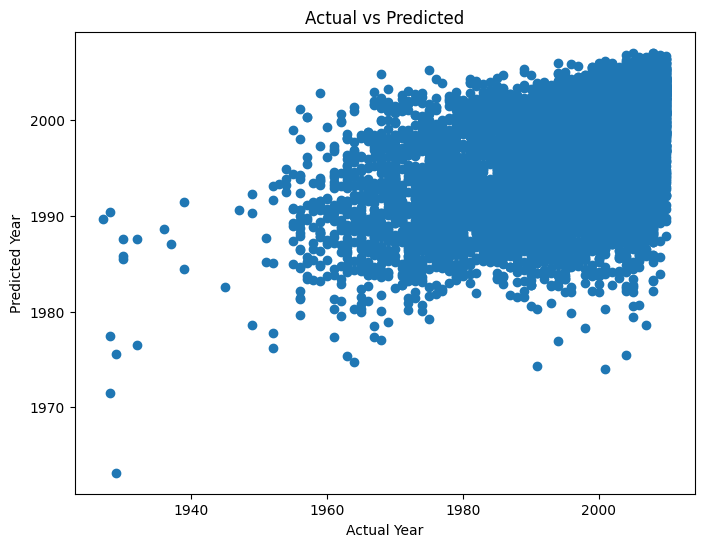

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")

plt.title("Actual vs Predicted")

plt.show()

Explanation
This graph shows how close the model’s predictions are to the actual values. By comparing the predicted values with the real values, we can evaluate the performance of the model visually.
If the points on the graph are closer together and follow the same pattern, it indicates that the model performs better and produces more accurate predictions.

## Interpretation

The Random Forest Regression model was able to predict song release years reasonably well.
The evaluation results show that the model achieved a good R² score and relatively low error values.

This indicates that the audio features contain useful information for predicting the release year of songs.

### Hyperparameter Tuning menggunakan Optuna

What is Hyperparameter Tuning?

When building a machine learning model such as RandomForestRegressor(), there are several parameters that can be adjusted, including the number of trees, tree depth, minimum split value, and many others.

Usually, we do not know which combination of parameters will produce the best model performance. Therefore, hyperparameter tuning is used to automatically search for the optimal parameter combination.

One popular tool for this process is Optuna, which helps find the best parameters efficiently and automatically.

Simple Analogy

Imagine you are tuning a racing motorcycle and trying different engine settings to achieve the fastest speed. Each adjustment affects the motorcycle’s performance, so you keep testing until you find the best combination.

Optuna works in a similar way for machine learning models. It tries different parameter combinations, evaluates the results, and searches for the settings that produce the best model performance.

In [15]:
import optuna

Membuat Objective Function

In [16]:
def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 200)

    max_depth = trial.suggest_int('max_depth', 5, 30)

    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    return rmse

The trial.suggest_int() function is used by Optuna to test many different combinations of integer values automatically during the hyperparameter tuning process.

For example, Optuna may try parameter combinations such as:

n_estimators = 73
max_depth = 15

After selecting these values, the model is trained and evaluated to determine whether the results are good or not. Optuna will continue testing different combinations until it finds the parameters that produce the best model performance.

Jalankan Optuna

In [18]:
study = optuna.create_study(direction='minimize')

study.optimize(objective, n_trials=5)

[I 2026-05-09 09:00:30,142] A new study created in memory with name: no-name-48d5dd9c-f2e8-4d57-a1ee-b32df7c75567
[I 2026-05-09 09:26:14,342] Trial 0 finished with value: 9.11960566410251 and parameters: {'n_estimators': 173, 'max_depth': 23, 'min_samples_split': 10}. Best is trial 0 with value: 9.11960566410251.
[I 2026-05-09 09:40:11,573] Trial 1 finished with value: 9.443349732105796 and parameters: {'n_estimators': 192, 'max_depth': 8, 'min_samples_split': 5}. Best is trial 0 with value: 9.11960566410251.
[I 2026-05-09 09:49:42,123] Trial 2 finished with value: 9.185048801354158 and parameters: {'n_estimators': 68, 'max_depth': 20, 'min_samples_split': 10}. Best is trial 0 with value: 9.11960566410251.
[I 2026-05-09 10:14:26,539] Trial 3 finished with value: 9.11280901960771 and parameters: {'n_estimators': 165, 'max_depth': 24, 'min_samples_split': 7}. Best is trial 3 with value: 9.11280901960771.
[I 2026-05-09 10:24:36,283] Trial 4 finished with value: 9.185049690291585 and param

Explanation

The parameter direction='minimize' means that Optuna will try to minimize the evaluation metric used during the tuning process. In this case, the goal is to obtain the smallest possible RMSE value because a lower RMSE indicates better prediction accuracy.

Meanwhile, n_trials=10 means that Optuna will test 10 different combinations of hyperparameters. Each combination is evaluated, and the best result will be selected automatically based on the model’s performance.

Lihat Parameter Terbaik

In [19]:
print("Best Parameters:")
print(study.best_params)

print("\nBest RMSE:")
print(study.best_value)

Best Parameters:
{'n_estimators': 165, 'max_depth': 24, 'min_samples_split': 7}

Best RMSE:
9.11280901960771


Training Model Terbaik

In [20]:
best_params = study.best_params

best_model = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=24, min_samples_split=7, n_estimators=165,
                      n_jobs=-1, random_state=42)

Prediksi Model Terbaik

In [21]:
best_predictions = best_model.predict(X_test_scaled)

Evaluasi Model Terbaik

In [22]:
mse_best = mean_squared_error(y_test, best_predictions)

rmse_best = np.sqrt(mse_best)

mae_best = mean_absolute_error(y_test, best_predictions)

r2_best = r2_score(y_test, best_predictions)

print("MSE :", mse_best)
print("RMSE :", rmse_best)
print("MAE :", mae_best)
print("R2 Score :", r2_best)

MSE : 83.04328822784365
RMSE : 9.112809019607711
MAE : 6.545624404268808
R2 Score : 0.28536961652570203


## Hyperparameter Tuning Result

Optuna successfully improved the Random Forest Regression model by searching for the best hyperparameter combination.

After tuning, the model achieved better regression performance with lower RMSE and higher R² score compared to the initial model.

Tracking Machine Learning menggunakan MLflow

Setup MLflow

In [23]:
mlflow.set_experiment("Midterm_ML_Regression")

2026/05/09 10:53:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 10:53:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/09 10:53:55 INFO mlflow.tracking.fluent: Experiment with name 'Midterm_ML_Regression' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1778324035543, experiment_id='1', last_update_time=1778324035543, lifecycle_stage='active', name='Midterm_ML_Regression', tags={}, trace_location=None, workspace='default'>

Tracking Experiment

In [24]:
with mlflow.start_run():

    # Log parameter
    mlflow.log_param("n_estimators", best_params['n_estimators'])
    mlflow.log_param("max_depth", best_params['max_depth'])
    mlflow.log_param("min_samples_split", best_params['min_samples_split'])

    # Log metrics
    mlflow.log_metric("MSE", mse_best)
    mlflow.log_metric("RMSE", rmse_best)
    mlflow.log_metric("MAE", mae_best)
    mlflow.log_metric("R2 Score", r2_best)

    print("MLflow tracking completed!")

MLflow tracking completed!


Explanation

The mlflow.log_param() function is used to store the parameters used in the machine learning model. This helps track and record the configuration of each experiment.

Example:

n_estimators = 78

Meanwhile, the mlflow.log_metric() function is used to store the evaluation results of the model, such as accuracy or error values.

Example:

RMSE = 7.2

By using MLflow, all parameters and evaluation results can be recorded automatically, making experiments easier to monitor, compare, and reproduce in the future.

Hasil Tracking MLflow

In [25]:
!mlflow ui --host 0.0.0.0 --port 5000

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/05/09 10:55:46 INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
2026/05/09 10:55:46 INFO:     Started parent process [56266]
2026/05/09 10:56:06 INFO:     Started server process [56269]
2026/05/09 10:56:06 INFO:     Waiting for application startup.
2026/05/09 10:56:06 INFO:     Application startup complete.
2026/05/09 10:56:08 INFO:     Started server process [56271]
2026/05/09 10:56:08 INFO:     Waiting for application startup.
2026/05/09 10:56:08 INFO:     Application startup complete.
2026/05/09 10:56:10 INFO:     Started server process [56270]
2026/05/09 10:56:10 INFO:     Waiting for application startup.
2026/05/09 10:56:10 INFO:     Application star

In [26]:
print("===== MLFLOW TRACKING =====")

print("Best Parameters:")
print(best_params)

print("\nEvaluation Metrics:")
print("MSE :", mse_best)
print("RMSE :", rmse_best)
print("MAE :", mae_best)
print("R2 Score :", r2_best)

===== MLFLOW TRACKING =====
Best Parameters:
{'n_estimators': 165, 'max_depth': 24, 'min_samples_split': 7}

Evaluation Metrics:
MSE : 83.04328822784365
RMSE : 9.112809019607711
MAE : 6.545624404268808
R2 Score : 0.28536961652570203


## MLflow Tracking

MLflow was used to track the machine learning experiment, including the model parameters and evaluation metrics.

The tracked metrics include:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

This helps monitor and compare machine learning experiments efficiently.

LIME Interpretation

Membuat Nama Feature

In [27]:
feature_names = [f'feature_{i}' for i in range(X.shape[1])]

Membuat LIME Explainer

In [35]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode='regression',
    discretize_continuous=False,
    random_state=42
)

training_data refers to the training dataset that has already been processed using scaling techniques. Scaling is performed to normalize the feature values so that the model can learn more effectively and produce better performance.

Meanwhile, mode='regression' indicates that the machine learning task is a regression problem. In regression, the model predicts continuous numerical values, such as predicting the year of a song release. This is different from classification tasks, where the model predicts categories or labels.

memilih satu data

In [36]:
sample_index = 0

Generate Explanation

In [43]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names,
    mode='regression',
    discretize_continuous=False,
    random_state=42
)

sample_data = X_test_lime[sample_index]

explanation = explainer.explain_instance(
    data_row=sample_data,
    predict_fn=best_model.predict,
    num_features=5
)

In [44]:
exp_list = explanation.as_list()

for item in exp_list:
    print(item)

('feature_0', 1.913894472429244)
('feature_2', -1.197498840059774)
('feature_13', 1.030157489511398)
('feature_5', -0.708027089251565)
('feature_19', 0.6123000080150494)


Example output:

('feature_0', 1.91)
('feature_2', -1.19)
('feature_13', 1.03)

These values show how each feature influences the model’s prediction.

feature_0 → +1.91

This feature has a strong positive influence on the predicted song year. It increases the prediction result significantly.

feature_2 → -1.19

This feature has a negative influence on the prediction, meaning it lowers the predicted song year.

feature_13 → +1.03

This feature also contributes positively and helps increase the predicted song year.

In general:

Positive values (+) increase the prediction result.
Negative values (-) decrease the prediction result.
Larger absolute values indicate stronger influence on the model’s prediction.

## LIME Interpretation Result

The LIME explanation shows the most influential audio features used by the Random Forest Regression model to predict the song release year.

Positive values indicate that the feature increases the predicted release year, while negative values decrease the prediction.

This interpretation helps improve the transparency and explainability of the machine learning model.